# G3-01 Isaac Lab Task Port and Throughput (Baseline)

- **Window:** July 27 to August 21 (weeks 1-4).
- **People:** Christian Coffrant (lead); Gwen Sarapata (support).
- **Data:** own bounding-geometry scene (start immediately).
- **Inputs:** starter `free_flyer_env.py`; Isaac Lab 3.0.0-beta2 at `/data/shared/env/IsaacLab`.
- **Outputs:** an Isaac Lab task config for the free-flyer inspection task, a smoke training run, and measured env-steps/s on this stack (the ~147k steps/s figure was the prior generation; re-measure).
- **Acceptance bar:** trains headless under Slurm on one GPU; checkpoint and resume verified (kill/resume drill); throughput recorded in MLflow (drives sweep sizing at M4).
- **Feeds:** all PPO work; GPU budget planning.

## Inspect `free_flyer_env.py`

In [15]:
from pathlib import Path
import ast
import textwrap

file_path = Path("../free_flyer_env.py")
src = file_path.read_text(encoding="utf-8")
lines = src.splitlines()

print("[File]", file_path)
for i, line in enumerate(lines[:30], 1):
    print(f"{i:02d}: {line}")

tree = ast.parse(src)
doc = ast.get_docstring(tree) or ""
classes = [n.name for n in tree.body if isinstance(n, ast.ClassDef)]
funcs = [n.name for n in tree.body if isinstance(n, ast.FunctionDef)]

print()
print("[Top-level classes]", classes)
print("[Top-level functions]", funcs)


[File] ../free_flyer_env.py
01: #!/usr/bin/env python3
02: """6-DoF zero-g free-flyer inspection environment for JWST-Inspect (Group 3).
03: 
04: Real local rigid-body dynamics (Newton-Euler) for a non-contact inspector around
05: the JWST target at the origin, with the published safety geometry: approach
06: corridor, keep-out zone, standoff target, abort boundary, and a relative-velocity
07: limit. Reward couples viewpoint coverage of the target, standoff hold, fuel use,
08: and safety. The observation is state-based (relative pose/vel + coverage + safety
09: flags); the rasterized-vs-path-traced visual study swaps the *rendered* observation
10: in eval_r2p.py via the Benchmark Replicator pipeline - the dynamics are identical.
11: 
12: Vectorized over `num_envs` with numpy for fast PPO. Every constant is an env knob.
13: This module is framework-agnostic (no Isaac dependency) so it trains on the jwst-rl
14: stack; the same task is also exposed as an Isaac Lab task scaffold for the
15

**This file itself is not an Isaac Lab environment at all.** It is a simplified reference environment that uses **NumPy to manually compute the physics**. The actual goal of G3-01 is to port the “rules of the game” defined here into a real **Isaac Lab + PhysX** environment.

Currently:
```
free_flyer_env.py
        ↓
Physics computed manually with NumPy
        ↓
Position, Velocity, Thrust, Reward, Safety zones, Coverage
```

Turning into:
```
Same game rules Ported into Isaac Lab
        ↓
Isaac Sim
        ↓
PhysX computes the actual rigid-body dynamics
        ↓
Run hundreds / thousands of spacecraft in parallel on the GPU
        ↓
PPO training
```

In [26]:
import os
import sys
sys.path.append("../../..")
#print(os.getcwd())

Testing the code by giving it +X direction thrust for 10 times:

`action = [ax, ay, az, tx, ty, tz]`

1. `ax`: normalized thrust command along the X axis  
2. `ay`: normalized thrust command along the Y axis  
3. `az`: normalized thrust command along the Z axis  
4. `tx`: normalized torque command around the X axis (roll)  
5. `ty`: normalized torque command around the Y axis (pitch)  
6. `tz`: normalized torque command around the Z axis (yaw)

For example `[[1, 0, 0, 0, 0, 0]]`means full positive X thrust, with zero thrust on Y/Z and zero torque on all rotation axes.

**This is the so called 6-Degree of Freedom.**

In [27]:
from autonomous.src.free_flyer_env import FreeFlyerVecEnv
import numpy as np

env = FreeFlyerVecEnv(num_envs=1, seed=42)

obs = env.reset()

print("initial position:", env.pos[0])
print("initial distance:", np.linalg.norm(env.pos[0]))

for i in range(10):
    action = np.array([[1, 0, 0, 0, 0, 0]])
    obs, reward, done, info = env.step(action)

print("final position:", env.pos[0])
print("final distance:", np.linalg.norm(env.pos[0]))
print("velocity:", env.vel[0])
print("info:", info)

initial position: [ -0.229217  -11.638018   11.9975644]
initial distance: 16.716385818018797
final position: [ -0.19491116 -11.63669738  12.02010922]
final distance: 16.731220578850188
velocity: [0.05305584 0.00132061 0.02254482]
info: {'coverage': array([0.125]), 'standoff_err': array([1.73122058]), 'in_keepout': array([False]), 'abort': array([False]), 'speed': array([0.05766225]), 'timeout': array([False])}


---

## Inspect `scripted_policy.py`

In [28]:
file_path = Path("../scripted_policy.py")
src = file_path.read_text(encoding="utf-8")
lines = src.splitlines()

print("[File]", file_path)
for i, line in enumerate(lines[:30], 1):
    print(f"{i:02d}: {line}")

tree = ast.parse(src)
doc = ast.get_docstring(tree) or ""
classes = [n.name for n in tree.body if isinstance(n, ast.ClassDef)]
funcs = [n.name for n in tree.body if isinstance(n, ast.FunctionDef)]

print()
print("[Top-level classes]", classes)
print("[Top-level functions]", funcs)

[File] ../scripted_policy.py
01: #!/usr/bin/env python3
02: """Scripted inspection baseline + the credibility hard gate (Group 3).
03: 
04: A deterministic, known-safe controller: hold the standoff distance, orbit the target
05: to gain viewpoint coverage, stay out of the keep-out zone, cap relative velocity, and
06: abort cleanly. This is the policy learned baselines must beat. `gate()` runs it on the
07: real env and asserts it respects approach corridor / standoff / keep-out / abort with
08: zero safety violations - by project rule this gate must pass before any learned-policy
09: headline claim. Controller gains are env knobs.
10: 
11:   python scripted_policy.py            # runs the hard gate, exits non-zero on failure
12: """
13: import os
14: import sys
15: import numpy as np
16: 
17: from free_flyer_env import FreeFlyerVecEnv, FreeFlyerConfig, knob
18: 
19: 
20: class ScriptedInspector:
21:     """PD station-keeping + slow orbit, operating on full state (a known-safe expert)."

This is a starter code to keep the inspector approximately 15 meters away from the JWST, slowly fly around it, and avoid entering the keep-out zone.

```
Generate 32 virtual inspectors
        ↓
Let the scripted controller fly them automatically
        ↓
Run for 2,400 steps
        ↓
Check:
- Did any inspector enter the keep-out zone?
- Did any inspector fly too fast?
- Did they achieve sufficient inspection coverage?
        ↓
PASS / FAIL
```

Let's try running it:

In [30]:
!python ../scripted_policy.py

scripted gate: final_coverage=0.434 mean_standoff_err=1.865m keepout_breaches=0 aborts=0 max_speed=0.300m/s
GATE PASS


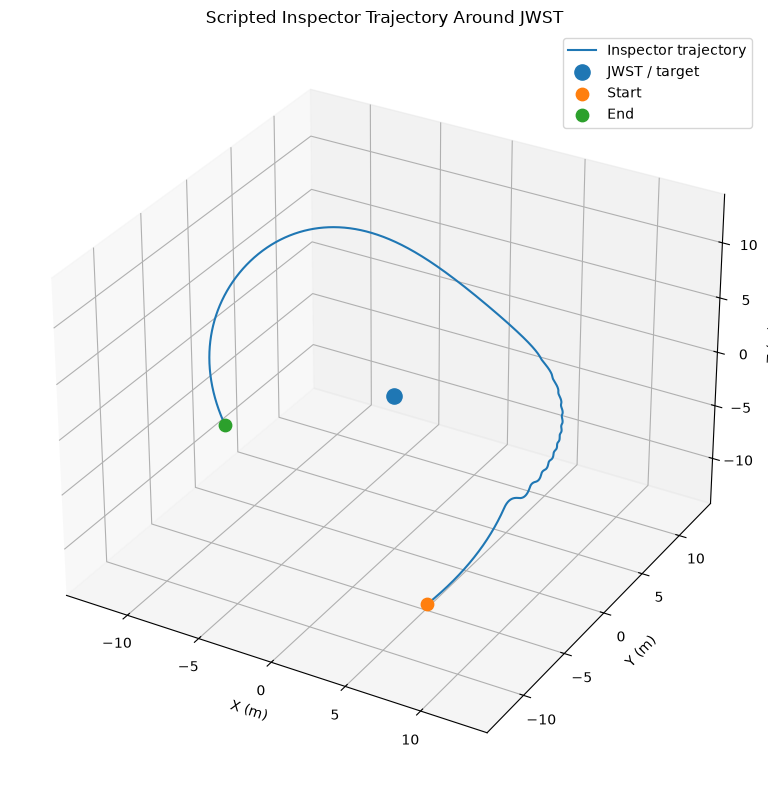

Steps: 2399
Start: [  4.80857149  -4.41248926 -14.33485688]
End:   [ -3.39911351 -13.39416078   5.03035723]
Info:  {'coverage': array([0.546875]), 'standoff_err': array([0.29610613]), 'in_keepout': array([False]), 'abort': array([False]), 'speed': array([0.29721741]), 'timeout': array([ True])}


In [36]:
import sys
sys.path.append("..")

from free_flyer_env import FreeFlyerVecEnv, FreeFlyerConfig
from scripted_policy import ScriptedInspector
import numpy as np
import matplotlib.pyplot as plt

cfg = FreeFlyerConfig()
env = FreeFlyerVecEnv(num_envs=1, cfg=cfg, seed=7)
policy = ScriptedInspector(cfg)

trajectory = [env.pos[0].copy()]

for step in range(2400):
    action = policy.act(env)
    _, _, done, info = env.step(action)

    # step() automatically resets when the episode ends, so don't record the reset position.
    if done[0]:
        break

    trajectory.append(env.pos[0].copy())

trajectory = np.array(trajectory)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

# Inspector trajectory
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    label="Inspector trajectory"
)

# JWST is currently represented by the origin
ax.scatter(0, 0, 0, s=120, label="JWST / target")

# Start and end
ax.scatter(*trajectory[0], s=80, label="Start")
ax.scatter(*trajectory[-1], s=80, label="End")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Scripted Inspector Trajectory Around JWST")
ax.legend()

# Make axes roughly equal scale
max_range = np.abs(trajectory).max()
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)
ax.set_zlim(-max_range, max_range)

plt.tight_layout()
plt.show()

print("Steps:", len(trajectory) - 1)
print("Start:", trajectory[0])
print("End:  ", trajectory[-1])
print("Info: ", info)

**So, yes, the most basic baseline has already built for us. We are not here to reinvent “a point flying around another point.” Our real task is to turn this toy baseline into a research-grade autonomous inspection system.**

**Port this toy free-flyer into the actual Isaac Sim / Isaac Lab environment.**

The existing `free_flyer_env.py` serves as the input/reference. The actual deliverable is an **Isaac Lab task configuration for the free-flyer inspection task** that supports **headless GPU training**.

Now:
```
NumPy:
A mathematical point
orbiting
another mathematical point
```

Turning into:
```
Isaac Sim / PhysX:

Real rigid-body inspector
        ↓
Real 6-DoF physics
        ↓
JWST / bounding geometry
        ↓
Keep-out / standoff / collision geometry
        ↓
Camera / sensors
```

---

## Game Rules

### 1. `FreeFlyerConfig` = World Parameter Settings

In [40]:
dt = 0.1            # Simulation time step
mass = 12.0         # Inspector mass in kg
inertia = 0.8       # Inspector inertia in kg·m²
max_thrust = 0.5    # 0.5 N, N = Newton
max_torque = 0.05   # 0.05 N·m

keepout = 8         # Keepout distance in meters
standoff = 15       # Standoff distance in meters
abort = 6           # Abort distance in meters
max_range = 40      # Maximum range in meters
velocity_limit = 0.5 # 0.5 m/s

Topology:
```
                  Too Far
             > 40 m → ABORT

                inspector
                    🛰️
                 15 m
          ← desired standoff →

             8 m boundary
        ┌─────────────────┐
        │    KEEP OUT     │
        │                 │
        │      JWST       │
        │        🔭       │
        │                 │
        └─────────────────┘

             < 6 m
           Force ABORT
```

### 2. `FreeFlyerVecEnv` = Training World

`class FreeFlyerVecEnv` is the vectorized environment. Using `FreeFlyerVecEnv(num_envs=256)` means to have 256 worlds running at the sametime for reinforcement learning. So measuring env-steps/s is one of the deliverables once our pipeline is finished.

### 3. `action` = A button that AI can push

`self.act_dim = 6self.act_dim = 6` means action dimension = 6. They are X, Y, Z thrust and torque, normalized between -1 and +1.

For example, `[1, 0, 0, 0, 0, 0]` means `F = action[:, :3] * max_thrust`, equals to `1 × 0.5 N = +0.5 N`, that is `-0.5 N` thurst to the opposite direction.

### 4. `observation` = The eyes of AI

`self.obs_dim = 13` comes back with 13 numbers:

```
3 position
+
3 velocity
+
3 angular values
+
1 standoff error
+
1 coverage
+
1 speed
+
1 range
----------------
= 13
```

AI or the model we build will use these numbers to determine an action.

```
        observation
            ↓
           PPO
            ↓
          action
            ↓
       Environment
            ↓
      physics happens
            ↓
 observation + reward
            ↓
           PPO
```

This is the center loop for G03-01.

### 5. `reward` = Scores for AI

```
reward =
    + coverage
    - standoff error
    - fuel
    - safety violation
    - velocity violation
```

To be specific:
```
coverage       × +10
standoff error × -0.5
fuel           × -0.05
safety         × -50
velocity       × -0.5
```

### 6. `coverage`

The start code uses a sphere / a dot to represent JWST: `self.patches = _fib_sphere(64)`

```
              •
        •           •
     •                 •

   •        JWST         •

     •                 •
        •           •
              •
```

There are 64 patches, and the inspector "looks" at it from different angles. Whenever it sees new patches: `coverage ↑  reward ↑`. It's a bounding-geometry stub, aka. a placeholder.

### 7. Undefined and unused items in the starter code

- `corridor_half_deg` = `self.corridor_half_deg = 20.0`
- `imu_bias` = `self.imu_bias = 0.0`. IMU = Inertial Measurement Unit
- Rotational dynamics: `self.ang += (tau / inertia) * dt`

---

## TO-DO:

```
free_flyer_env.py
      │
      │ Already defines:
      │
      ├─ mass
      ├─ thrust
      ├─ torque
      ├─ observation
      ├─ reward
      ├─ standoff
      ├─ keep-out
      ├─ abort
      ├─ coverage
      └─ episode
              │
              ↓
      Port these definitions
         into Isaac Lab
              │
              ↓
      PhysX handles the physics
              │
              ↓
         PPO can be trained
```

### Implementation Stages

1. **Issac Lab environment:** Run Issac Lab, generate Inspector rigid body, zero gravity, reset, random 6D action, aircraft moves, observation returns
2. **Port `free_flyer_env.py` game rules over:** standoff, keep-out, abort, velocity limit, coverage, reward, episode termination
3. **PPO smoke training:** very basic, environment → PPO → action → environment
4. **Headless + Slurm + checkpoint/resume**
5. **Benchmark throughput:** test 64 envs, 128 envs, ... and get env-steps/s, record to MLflow

*Bottomline*: Port this NumPy-based set of game rules into a **free-flyer reinforcement-learning environment managed by Isaac Lab, simulated by PhysX, and executed in parallel on the GPU.**

---

## **Implementation One:** Issac Lab environment

- Isaac Sim 
    - = game engine 
    - = JWST + Inspector + PhysX
    - = physics + 6-DoF + sensors
- Isaac Lab 
    - = AI training field 
    - = Observation + Action + Score + Next Step
    - with PyTorch = scripted baseline + behavior cloning + PPO (Proximal policy optimization)
- OpenUSD
    - Scene ≠ Environment
    - OpenUSD describes what's in the 3D world: JWST, Inspector, Camera, Light, KeepOutZone, Corridor, Materials
    - ...and their metadata: JWST location, Inspector location, how they look like, what material, layer structures
    - **OpenUSD Scene = Map**
    - **Issac Lab Environment = Map + Game Rule**
        - Los Santos map file ≠ GTA game
        - `jwst_scene.usd` ≠ `Issac-JWST-Inspect-v0`

AI gives action to Environment, Environment gives back observation, reward, and etc back to AI. Repeat. Pseudocode example of reinforcement learning:
```
obs = env.reset()
while True:
    action = policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
```

For **`Isaac-JWST-Inspect-v0` environment**, the mental model looks like:
```
`reset()`
↓
Give Inspector an initial location
↓
Return observation

`step(action)`
↓
Give thrust / torque to PhysX
↓
PhysX updates aircraft's location
↓
Calculate standoff
↓
Calculate keep-out
↓
Calculate coverage
↓
Calculate reward
↓
Check abort / success
↓
Return new observation
```

**MDP (Markov Decision Process)**

Inspector: 
- State: the state of the world
    - Position, velocity, orientation, angular velocity, distance to JWST, ...
    - Example: `x = 10m, y = 2m, z = 1m, vs = -0.3m/s`
- Observation: what AI actually sees, might not be the same as Stage
    - For example, the actual world knows 

Target deliverables:
```
mdp/
├── observations.py
│   What AI sees?
│
├── rewards.py
│   How AI scores?
│
├── terminations.py
│   When this round finishes?
│
└── events.py
    What to do when `reset` or other events occurs?
```